In [1]:
import numpy as np

In [2]:
max_rotatoin = [180, 50, 75, 90, 60]
min_rotatoin = [-180, -90, -75, -90, -60]

link_length = [100, 333, [117, 358], 100]

In [26]:
import numpy as np

LINK_LENGTH = [100, 333, [117, 358], 100]

def fk(theta):

    A0 = np.array([
        [np.cos(theta[0]), -np.sin(theta[0]), 0, 0],
        [np.sin(theta[0]),  np.cos(theta[0]), 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 1]
    ])

    A1 = np.array([
        [np.cos(theta[1]), 0, -np.sin(theta[1]), LINK_LENGTH[0]],
        [0, 1, 0, 0],
        [np.sin(theta[1]), 0, np.cos(theta[1]), 0],
        [0, 0, 0, 1]
    ])

    theta2_prime = theta[2] + np.radians(71.9)

    A2 = np.array([
        [np.cos(theta2_prime), 0, -np.sin(theta2_prime), 0],
        [0, 1, 0, 0],
        [np.sin(theta2_prime), 0, np.cos(theta2_prime), LINK_LENGTH[1]],
        [0, 0, 0, 1]
    ])

    A3 = np.array([
        [1, 0, 0, LINK_LENGTH[2][0]],
        [0, np.cos(theta[3]), -np.sin(theta[3]), 0],
        [0, np.sin(theta[3]), np.cos(theta[3]), LINK_LENGTH[2][1]],
        [0, 0, 0, 1]
    ])

    A4 = np.array([
        [np.cos(theta[4]), 0, -np.sin(theta[4]), 0],
        [0, 1, 0, 0],
        [np.sin(theta[4]), 0, np.cos(theta[4]), 0],
        [0, 0, 0, 1]
    ])

    A5 = np.array([
        [1, 0, 0, LINK_LENGTH[3]],
        [0, 1, 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 1]
    ])

    T = A0 @ A1 @ A2 @ A3 @ A4 @ A5

    pos = T[:3, 3]

    return pos

def jacobian(theta, eps=1e-6):

    theta = np.asarray(theta, dtype=float)

    J = np.zeros((3, len(theta)))

    p0 = fk(theta)

    for i in range(len(theta)):

        th = theta.copy()
        th[i] += eps

        p1 = fk(th)

        J[:, i] = (p1 - p0) / eps

    return J

def inverse_kinematics(
        target,
        theta_init=None,
        max_iter=1000,
        tolerance=1e-3,
        alpha=0.3):

    if theta_init is None:
        theta = np.zeros(5)
    else:
        theta = np.array(theta_init, dtype=float)



    for i in range(max_iter):

        current = fk(theta)

        error = target - current

        if np.linalg.norm(error) < tolerance:
            print(f"Converged in {i} iterations")
            return theta

        J = jacobian(theta)

        dtheta = alpha * np.linalg.pinv(J) @ error

        theta += dtheta

    print("Failed to converge")
    return theta

target = np.array([
    300,
    200,
    500
])

theta_solution = inverse_kinematics(
    target,
    theta_init=np.radians([0, 0, 0, 0, 0])
)

print("\nJoint Angles (deg)")
print(np.degrees(theta_solution))

print("\nFK Check")
print(fk(theta_solution))

print("\nTarget")
print(target)

Converged in 38 iterations

Joint Angles (deg)
[-131.59133468   12.41803432    0.25375788  110.33895077  -77.68280488]

FK Check
[299.99943068 199.99930844 499.99989908]

Target
[300 200 500]


Converged in 385 iterations
Converged in 37 iterations
Converged in 37 iterations
Converged in 37 iterations
Converged in 34 iterations
Failed to converge
Converged in 31 iterations
Converged in 37 iterations
Converged in 35 iterations
Converged in 38 iterations


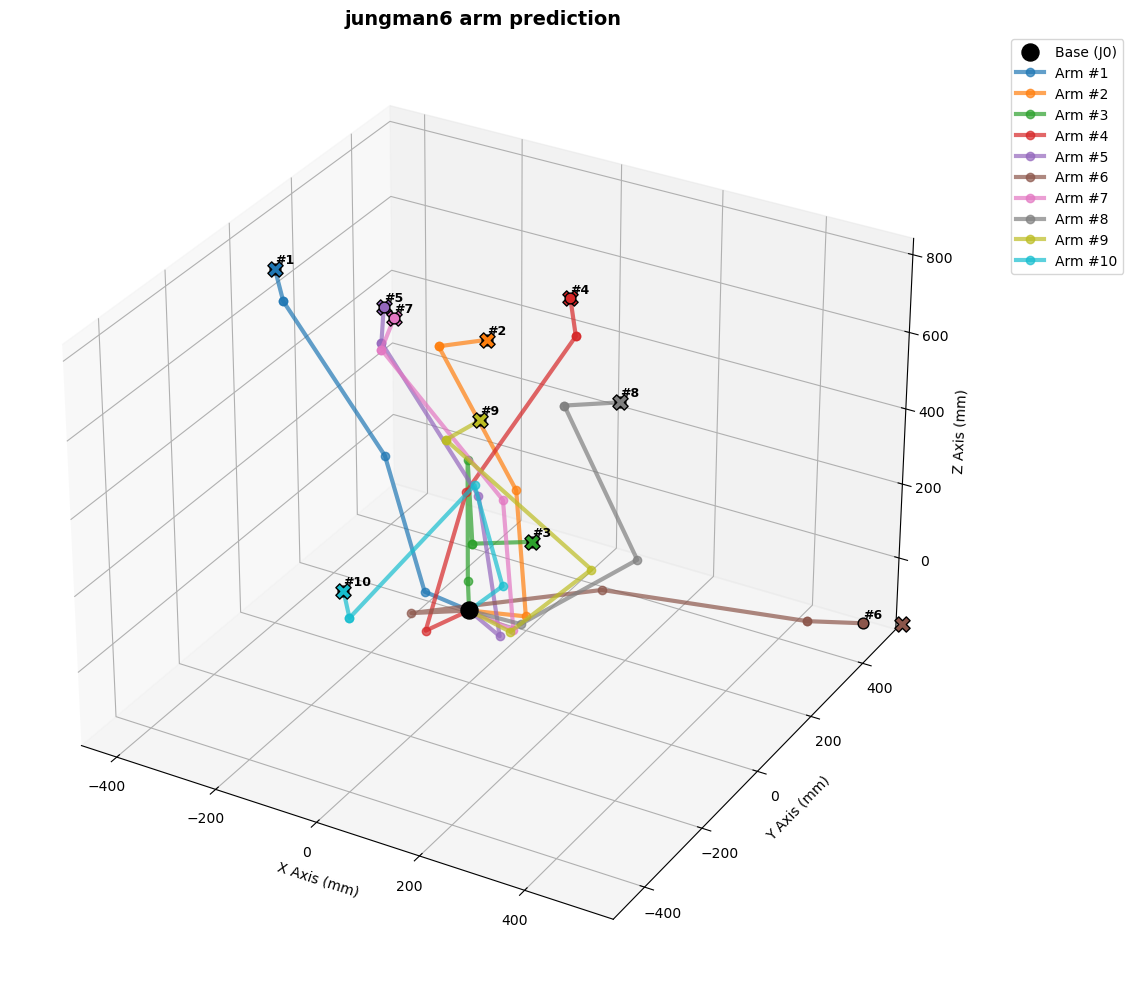

In [27]:
import numpy as np
import joblib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


def get_trans(theta, link_length):
    A0 = np.array([
        [np.cos(theta[0]), -np.sin(theta[0]), 0, 0],
        [np.sin(theta[0]),  np.cos(theta[0]), 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 1]
    ])

    A1 = np.array([
        [np.cos(theta[1]), 0, -np.sin(theta[1]), link_length[0]],
        [0, 1, 0, 0],
        [np.sin(theta[1]), 0, np.cos(theta[1]), 0],
        [0, 0, 0, 1]
    ])

    theta2_prime = theta[2] + np.radians(71.9)

    A2 = np.array([
        [np.cos(theta2_prime), 0, -np.sin(theta2_prime), 0],
        [0, 1, 0, 0],
        [np.sin(theta2_prime), 0, np.cos(theta2_prime), link_length[1]],
        [0, 0, 0, 1]
    ])

    A3 = np.array([
        [1, 0, 0, link_length[2][0]],
        [0, np.cos(theta[3]), -np.sin(theta[3]), 0],
        [0, np.sin(theta[3]), np.cos(theta[3]), link_length[2][1]],
        [0, 0, 0, 1]
    ])

    A4 = np.array([
        [np.cos(theta[4]), 0, -np.sin(theta[4]), 0],
        [0, 1, 0, 0],
        [np.sin(theta[4]), 0, np.cos(theta[4]), 0],
        [0, 0, 0, 1]
    ])

    A5 = np.array([
        [1, 0, 0, link_length[3]],
        [0, 1, 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 1],
    ])

    A = [A0, A1, A2, A3, A4, A5]
    T = np.eye(4)
    joints = [[0, 0, 0]]

    for Ai in A:
        T = T @ Ai
        joints.append(T[:3, 3].copy())

    return np.array(joints)

def plot_multiple_robot_arms(all_joints, all_targets):
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    colors = plt.cm.tab10(np.linspace(0, 1, len(all_joints)))
    ax.scatter(0, 0, 0, color='black', s=150, zorder=10, label='Base (J0)')

    total_x, total_y, total_z = [], [], []

    for idx, (joints, target_xyz) in enumerate(zip(all_joints, all_targets)):
        x, y, z = joints[:, 0], joints[:, 1], joints[:, 2]
        total_x.extend(x); total_y.extend(y); total_z.extend(z)

        ax.plot(x, y, z, '-o', color=colors[idx], linewidth=3, markersize=6, alpha=0.7,
                label=f'Arm #{idx+1}')
        ax.scatter(x[-1], y[-1], z[-1], color=colors[idx], s=60, edgecolors='black', zorder=5)

        ax.scatter(target_xyz[0], target_xyz[1], target_xyz[2],
                   color=colors[idx], marker='X', s=120, edgecolors='black', zorder=6)

        ax.text(x[-1], y[-1], z[-1] + 15.0, f"#{idx+1}", color='black', fontsize=9, fontweight='bold')

    ax.set_xlabel('X Axis (mm)')
    ax.set_ylabel('Y Axis (mm)')
    ax.set_zlabel('Z Axis (mm)')
    ax.set_title('jungman6 arm prediction', fontsize=14, fontweight='bold')

    total_x, total_y, total_z = np.array(total_x), np.array(total_y), np.array(total_z)
    max_range = np.array([total_x.max()-total_x.min(), total_y.max()-total_y.min(), total_z.max()-total_z.min()]).max() / 2.0
    mid_x = (total_x.max()+total_x.min())*0.5
    mid_y = (total_y.max()+total_y.min())*0.5
    mid_z = (total_z.max()+total_z.min())*0.5

    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)

    ax.grid(True)
    ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.show()

def get_valid_random_target(link_lengths, min_dist=400.0, max_dist=900.0):
    max_rotation = [180, 50, 75, 90, 60]
    min_rotation = [-180, -90, -75, -90, -60]

    min_limits = np.radians(min_rotation)
    max_limits = np.radians(max_rotation)

    while True:
        rand_theta = [np.random.uniform(min_limits[i], max_limits[i]) for i in range(5)]
        joints = get_trans(rand_theta, link_lengths)
        ee_pure = joints[-1]

        distance = np.linalg.norm(ee_pure)

        if min_dist <= distance <= max_dist:
            A0 = np.array([[np.cos(rand_theta[0]), -np.sin(rand_theta[0]), 0, 0], [np.sin(rand_theta[0]), np.cos(rand_theta[0]), 0, 0], [0,0,1,0], [0,0,0,1]])
            A1 = np.array([[np.cos(rand_theta[1]), 0, -np.sin(rand_theta[1]), link_lengths[0]], [0,1,0,0], [np.sin(rand_theta[1]), 0, np.cos(rand_theta[1]), 0], [0,0,0,1]])
            A2 = np.array([[np.cos(rand_theta[2]+np.radians(71.9)), 0, -np.sin(rand_theta[2]+np.radians(71.9)), 0], [0,1,0,0], [np.sin(rand_theta[2]+np.radians(71.9)), 0, np.cos(rand_theta[2]+np.radians(71.9)), link_lengths[1]], [0,0,0,1]])
            A3 = np.array([[1,0,0,link_lengths[2][0]], [0,np.cos(rand_theta[3]),-np.sin(rand_theta[3]),0], [0,np.sin(rand_theta[3]),np.cos(rand_theta[3]),link_lengths[2][1]], [0,0,0,1]])
            A4 = np.array([[np.cos(rand_theta[4]), 0, -np.sin(rand_theta[4]), 0], [0,1,0,0], [np.sin(rand_theta[4]), 0, np.cos(rand_theta[4]), 0], [0,0,0,1]])
            A5 = np.array([[1,0,0,link_lengths[3]], [0,1,0,0], [0,0,1,0], [0,0,0,1]])
            T = A0 @ A1 @ A2 @ A3 @ A4 @ A5

            r11, r21, r31 = T[0, 0], T[1, 0], T[2, 0]
            r32, r33 = T[2, 1], T[2, 2]

            yaw = np.arctan2(r21, r11)
            pitch = np.arctan2(-r31, np.sqrt(r32**2 + r33**2))
            roll = np.arctan2(r32, r33)

            target_pos = [ee_pure[0], ee_pure[1], ee_pure[2], roll, pitch, yaw]
            return target_pos

def main():

    link_lengths = [100, 333, [117, 358], 100]

    target_list = []
    predicted_joints_list = []

    for i in range(10):
        target_position = get_valid_random_target(link_lengths, min_dist=400.0, max_dist=900.0)
        target_list.append(target_position)

        target_xyz = np.array(target_position[:3])

        predicted_theta = inverse_kinematics(
            target_xyz,
            theta_init=np.radians([0, 0, 0, 0, 0])
        )

        joint_positions = get_trans(predicted_theta, link_lengths)
        predicted_joints_list.append(joint_positions)

    plot_multiple_robot_arms(predicted_joints_list, [t[:3] for t in target_list])

if __name__ == "__main__":
    main()